Importación de librerías y carga de dataset

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import re
import spacy

TRAIN_PATH = Path("../data/raw/ag_news_train.csv")
TEST_PATH = Path("../data/raw/ag_news_test.csv")

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

df = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

print("Dimensiones del dataset:")
print(df.shape)

print("\nColumnas disponibles:")
print(df.columns.tolist())

df.head()

Dimensiones del dataset:
(127600, 3)

Columnas disponibles:
['Class Index', 'Title', 'Description']


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


 Mapeo de etiquetas

In [2]:
label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

df["category"] = df["Class Index"].map(label_map)

df[["Class Index", "category", "Title", "Description"]].head()

,Class Index,category,Title,Description
0,3,Business,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Business,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Business,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Business,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,Business,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


 Información general del dataset

In [3]:
print("Información general del dataset:")
df.info()

Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 127600 entries, 0 to 127599
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Class Index  127600 non-null  int64
 1   Title        127600 non-null  str  
 2   Description  127600 non-null  str  
 3   category     127600 non-null  str  
dtypes: int64(1), str(3)
memory usage: 3.9 MB


Análisis de valores nulos

In [4]:
print("Valores nulos por columna:")
df.isnull().sum().sort_values(ascending=False)

Valores nulos por columna:


Class Index    0
Title          0
Description    0
category       0
dtype: int64

 Revisión de registros duplicados

In [5]:
print("Registros duplicados:")
df.duplicated().sum()

Registros duplicados:


np.int64(0)

Exploración inicial de registros

In [6]:
df.head(10)

,Class Index,Title,Description,category
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Business
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Business
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Business
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Business
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...",Business
5,3,"Stocks End Up, But Near Year Lows (Reuters)",Reuters - Stocks ended slightly higher on Frid...,Business
6,3,Money Funds Fell in Latest Week (AP),AP - Assets of the nation's retail money marke...,Business
7,3,Fed minutes show dissent over inflation (USATO...,USATODAY.com - Retail sales bounced back a bit...,Business
8,3,Safety Net (Forbes.com),Forbes.com - After earning a PH.D. in Sociolog...,Business
9,3,Wall St. Bears Claw Back Into the Black,"NEW YORK (Reuters) - Short-sellers, Wall Stre...",Business


Distribución de clases

In [7]:
print(df["category"].value_counts())

category
Business    31900
Sci/Tech    31900
Sports      31900
World       31900
Name: count, dtype: int64


Visualización de la distribución de clases

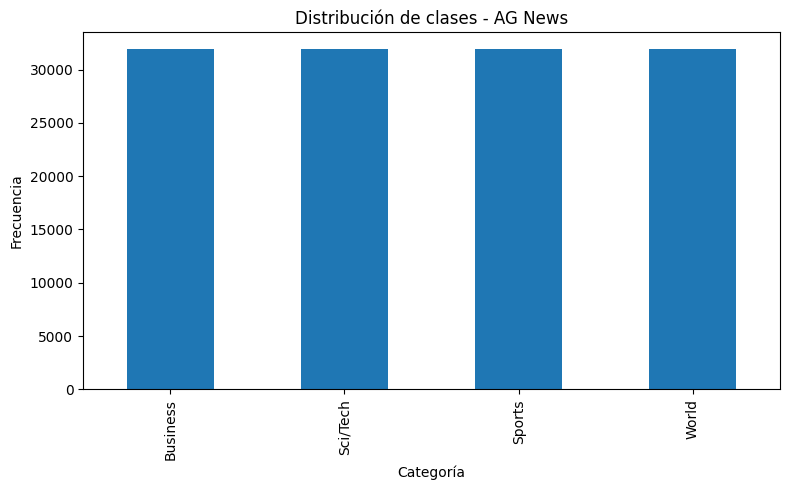

In [8]:
ax = df["category"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribución de clases - AG News")
plt.xlabel("Categoría")
plt.ylabel("Frecuencia")
plt.tight_layout()

plt.savefig(
    "../outputs/figures/distribucion_clases_ag_news.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Construcción de la variable textual

In [9]:
df["text"] = (
    df["Title"].fillna("")
    + " "
    + df["Description"].fillna("")
)

df[["Title", "Description", "text", "category"]].head()

,Title,Description,text,category
0,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...,Business
4,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new...",Business


Selección de variables para el modelo

In [10]:
X = df["text"]
y = df["category"]

print("Cantidad de textos:", X.shape[0])
print("Cantidad de etiquetas:", y.shape[0])

Cantidad de textos: 127600
Cantidad de etiquetas: 127600


Carga del modelo de spaCy

In [11]:
nlp = spacy.load("en_core_web_sm")

Normalización del texto

In [12]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

Aplicación de la normalización

In [13]:
df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back into the black reuters...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace reut...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil and economy cloud stocks outlook reuters r...
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports from main southern pipe...
4,"Oil prices soar to all-time record, posing new...",oil prices soar to all time record posing new ...


Validación de la preparación de datos

In [14]:
df.shape
df["category"].value_counts()
df[["text", "clean_text", "category"]].head()

,text,clean_text,category
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back into the black reuters...,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace reut...,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil and economy cloud stocks outlook reuters r...,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports from main southern pipe...,Business
4,"Oil prices soar to all-time record, posing new...",oil prices soar to all time record posing new ...,Business


Tokenización, eliminación de stopwords y lematización

In [15]:
def preprocess_texts(texts, batch_size=500):
    processed_texts = []

    for doc in nlp.pipe(texts, batch_size=batch_size):
        tokens = []

        for token in doc:
            if token.is_stop:
                continue

            if token.is_punct:
                continue

            if token.is_space:
                continue

            lemma = token.lemma_.strip()

            if len(lemma) < 2:
                continue

            tokens.append(lemma)

        processed_texts.append(" ".join(tokens))

    return processed_texts

Aplicación del preprocesamiento NLP

In [16]:
df["processed_text"] = preprocess_texts(
    df["clean_text"].tolist(),
    batch_size=500
)

df[["text", "clean_text", "processed_text", "category"]].head()

,text,clean_text,processed_text,category
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back into the black reuters...,wall st bears claw black reuter reuter short s...,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace reut...,carlyle look commercial aerospace reuters reut...,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil and economy cloud stocks outlook reuters r...,oil economy cloud stock outlook reuters reuter...,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports from main southern pipe...,iraq halt oil export main southern pipeline re...,Business
4,"Oil prices soar to all-time record, posing new...",oil prices soar to all time record posing new ...,oil price soar time record pose new menace eco...,Business


Validación de registros vacíos después del preprocesamiento

In [17]:
empty_processed = (df["processed_text"].str.strip() == "").sum()

print("Registros vacíos después del preprocesamiento:")
print(empty_processed)

Registros vacíos después del preprocesamiento:
0


Análisis de longitud del texto antes y después del preprocesamiento

In [18]:
df["original_word_count"] = df["text"].apply(lambda x: len(str(x).split()))
df["processed_word_count"] = df["processed_text"].apply(lambda x: len(str(x).split()))

df[["original_word_count", "processed_word_count"]].describe()

,original_word_count,processed_word_count
count,127600.000000,127600.000000
mean,37.837257,23.937492
std,10.091135,6.635402
min,4.000000,1.000000
25%,32.000000,20.000000
50%,37.000000,23.000000
75%,43.000000,27.000000
max,177.000000,119.000000


 Reducción promedio del texto

In [19]:
avg_original = df["original_word_count"].mean()
avg_processed = df["processed_word_count"].mean()

reduction_percentage = ((avg_original - avg_processed) / avg_original) * 100

print(f"Promedio de palabras antes del preprocesamiento: {avg_original:.2f}")
print(f"Promedio de palabras después del preprocesamiento: {avg_processed:.2f}")
print(f"Reducción promedio del texto: {reduction_percentage:.2f}%")

Promedio de palabras antes del preprocesamiento: 37.84
Promedio de palabras después del preprocesamiento: 23.94
Reducción promedio del texto: 36.74%


 Visualización de la reducción del texto

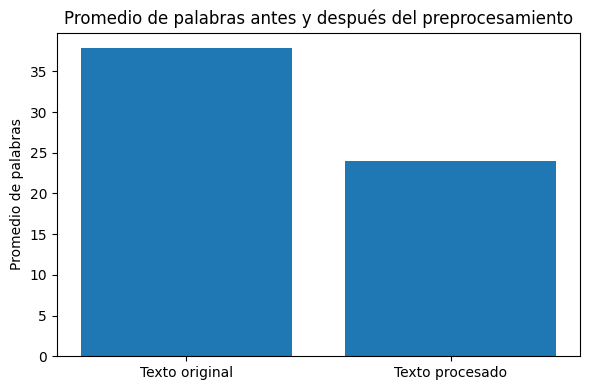

In [20]:
word_count_summary = {
    "Texto original": avg_original,
    "Texto procesado": avg_processed
}

plt.figure(figsize=(6, 4))
plt.bar(word_count_summary.keys(), word_count_summary.values())
plt.title("Promedio de palabras antes y después del preprocesamiento")
plt.ylabel("Promedio de palabras")
plt.tight_layout()

plt.savefig(
    "../outputs/figures/reduccion_texto_ag_news.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Guardado del dataset procesado

In [21]:
processed_path = "../data/processed/ag_news_processed.csv"

df.to_csv(processed_path, index=False)

print(f"Dataset procesado guardado en: {processed_path}")

Dataset procesado guardado en: ../data/processed/ag_news_processed.csv
